# S-PersistenceLOO

Leave-one-out robustness + CA tip subsampling sensitivity for volume and density persistence associations.

- 16 LOO rows (exclude one state, n=15)
- 3 CA subsampled rows (50%, 25%, 10% of CA tips, prune trees, recompute BT + intros, n=16)

In [1]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats as sp_stats

for font in ['Arial', 'Helvetica', 'DejaVu Sans']:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = [font]
        break
    except ValueError:
        continue

plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

PROJ_ROOT = Path('../..').resolve()
PAPER_DIR = PROJ_ROOT / 'paper' / 'final'
FINAL_DIR = PAPER_DIR
FIG_DIR = FINAL_DIR / 'figures'
BEAST_DIR = PAPER_DIR / 'analysis/beast'
_CORR2_DIR = BEAST_DIR / 'phylogeography/correlateSet2e'
TREE_FILE = _CORR2_DIR / 'timeinhomogeneous_correlateSet2enforced_weeklyEpochs_3era_3rateScalar.burninRemovedResampled.trees'

TREE_STATE_COLORS = {
    'CA': '#ff7f00', 'TX': '#e41a1c', 'ID': '#7b3294', 'CO': '#2166ac',
    'IA': '#1b9e77', 'MN': '#00838f', 'MI': '#8c6d31', 'OH': '#c51b7d',
    'NM': '#b2abd2', 'WY': '#a6d854', 'SD': '#fc8d62', 'KS': '#ffd92f',
    'UT': '#e5c494', 'NE': '#b3b3b3', 'OK': '#d9d9d9', 'NC': '#66c2a5',
}

def hpd(samples, credible_mass=0.95):
    sorted_samples = np.sort(samples)
    n = len(sorted_samples)
    interval_size = int(np.ceil(credible_mass * n))
    widths = sorted_samples[interval_size:] - sorted_samples[:n - interval_size]
    best = int(np.argmin(widths))
    return sorted_samples[best], sorted_samples[best + interval_size - 1]

def standardize(x):
    sd = x.std()
    if sd == 0: return np.zeros_like(x)
    return (x - x.mean()) / sd

def run_per_tree_regressions(df, response_col, pred_cols, exclude_states=None):
    trees = sorted(df['tree'].unique())
    n_preds = len(pred_cols)
    r2_arr = np.zeros((len(trees), n_preds))
    p_arr = np.ones((len(trees), n_preds))
    for ti, tree in enumerate(trees):
        td = df[df['tree'] == tree].copy()
        if exclude_states:
            td = td[~td['state'].isin(exclude_states)]
        if len(td) < 5: continue
        y = np.log(np.maximum(td[response_col].values, 1e-6))
        for pi, col in enumerate(pred_cols):
            x_raw = np.log(np.maximum(td[col].values.astype(float), 1e-10))
            x_z = standardize(x_raw)
            slope, intercept, r, p, se = sp_stats.linregress(x_z, y)
            r2_arr[ti, pi] = r ** 2
            p_arr[ti, pi] = p
    return {'r2': r2_arr, 'p': p_arr}

In [2]:
import pickle

RESULTS_PATH = FIG_DIR / 'persistence_loo_results.pkl'
RECOMPUTE = not RESULTS_PATH.exists()

bt_df = pd.read_csv(FIG_DIR / 'persistence_branch_times_225trees.csv')
pred = pd.read_csv(FINAL_DIR / 'data/covariates/network_predictors_1000nets_16states.csv')
df = bt_df.merge(pred, on='state', how='left')
states = sorted(df['state'].unique())
print(f"{df['tree'].nunique()} trees, {len(states)} states")

if RECOMPUTE:
    res_bt_full = run_per_tree_regressions(df, 'branch_time', ['mean_internal_volume', 'mean_internal_density'])
    res_bpi_full = run_per_tree_regressions(df, 'bt_per_intro', ['mean_internal_volume', 'mean_internal_density'])
    full_r2 = {
        'volume': {'BT': np.median(res_bt_full['r2'][:, 0]), 'BT/intro': np.median(res_bpi_full['r2'][:, 0])},
        'density': {'BT': np.median(res_bt_full['r2'][:, 1]), 'BT/intro': np.median(res_bpi_full['r2'][:, 1])},
    }
    print(f"Full R2: vol BT={full_r2['volume']['BT']:.3f}, dens BT={full_r2['density']['BT']:.3f}")
else:
    print(f'Cached results found at {RESULTS_PATH} — skipping computation')

225 trees, 16 states
Cached results found at /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures/persistence_loo_results.pkl — skipping computation


In [3]:
if RECOMPUTE:
    print('Running LOO...')
    loo_results = {}
    for feat, col in [('volume', 'mean_internal_volume'), ('density', 'mean_internal_density')]:
        loo_results[feat] = {}
        for resp, rcol in [('BT', 'branch_time'), ('BT/intro', 'bt_per_intro')]:
            d = {}
            for st in states:
                r = run_per_tree_regressions(df, rcol, [col], exclude_states={st})
                d[st] = r['r2'][:, 0]
            loo_results[feat][resp] = d
    print('Done LOO.')
else:
    print('Skipped LOO (cached)')

Skipped LOO (cached)


## CA tip pruning

In [4]:
if RECOMPUTE:
    class Node:
        __slots__ = ['children', 'label', 'length', 'state', 'history', 'is_tip']
        def __init__(self):
            self.children = []; self.label = None; self.length = 0.0
            self.state = None; self.history = []; self.is_tip = True

    def parse_newick_to_nodes(s):
        pos = [0]
        def read_bracket():
            assert s[pos[0]] == '['
            depth = 1; start = pos[0]; pos[0] += 1
            while pos[0] < len(s) and depth > 0:
                if s[pos[0]] == '[': depth += 1
                elif s[pos[0]] == ']': depth -= 1
                pos[0] += 1
            return s[start:pos[0]]
        def parse_annotation(node, ann):
            m = re.search(r'loc\.states="(\w+)"', ann)
            if m: node.state = m.group(1)
            for hm in re.finditer(r'history=\{\{(.*?)\}\}', ann):
                for mm in re.finditer(r'([\d.Ee+-]+),(\w+),(\w+)', hm.group(1)):
                    node.history.append((float(mm.group(1)), mm.group(2), mm.group(3)))
        def parse_node():
            node = Node()
            if s[pos[0]] == '(':
                node.is_tip = False; pos[0] += 1
                while True:
                    node.children.append(parse_node())
                    if pos[0] < len(s) and s[pos[0]] == ',': pos[0] += 1
                    elif pos[0] < len(s) and s[pos[0]] == ')': pos[0] += 1; break
                    else: break
            if pos[0] < len(s) and s[pos[0]] not in (':', '[', ',', ')', ';'):
                if s[pos[0]] == "'":
                    end = s.index("'", pos[0]+1); node.label = s[pos[0]+1:end]; pos[0] = end+1
                else:
                    start = pos[0]
                    while pos[0] < len(s) and s[pos[0]] not in (':', '[', ',', ')', ';'): pos[0] += 1
                    node.label = s[start:pos[0]]
            while pos[0] < len(s) and s[pos[0]] == '[':
                parse_annotation(node, read_bracket())
            if pos[0] < len(s) and s[pos[0]] == ':':
                pos[0] += 1
                while pos[0] < len(s) and s[pos[0]] == '[':
                    parse_annotation(node, read_bracket())
                start = pos[0]
                while pos[0] < len(s) and s[pos[0]] not in (',', ')', '[', '(', ';'): pos[0] += 1
                try: node.length = float(s[start:pos[0]])
                except: node.length = 0.0
            return node
        return parse_node()

    def prune_tips(node, keep):
        if node.is_tip: return node if node.label in keep else None
        ch = [c for c in (prune_tips(c, keep) for c in node.children) if c is not None]
        if not ch: return None
        if len(ch) == 1:
            ch[0].length += node.length
            ch[0].history = node.history + ch[0].history
            return ch[0]
        node.children = ch; return node

    def compute_bt(node):
        st = {}
        def add(s, t):
            if t > 0: st[s] = st.get(s, 0) + t
        def walk(n):
            if n.length > 0 and n.state:
                if not n.history: add(n.state, n.length)
                else:
                    h = sorted(n.history, key=lambda x: x[0], reverse=True)
                    it = 0
                    for i in range(1, len(h)):
                        seg = h[i-1][0] - h[i][0]
                        if seg > 0: it += seg; add(h[i-1][2], seg)
                    rem = n.length - it
                    if rem > 0: add(h[0][1], rem/2); add(h[-1][2], rem/2)
            for c in n.children: walk(c)
        walk(node); return st

    def count_intros(node):
        ic = {}
        def walk(n):
            for _, fr, to in n.history: ic[to] = ic.get(to, 0) + 1
            for c in n.children: walk(c)
        walk(node); ic['TX'] = ic.get('TX', 0) + 1; return ic

    print('Tree pruning functions defined.')
else:
    print('Skipped (cached)')

Skipped (cached)


In [5]:
if RECOMPUTE:
    print('Parsing translate block...')
    translate = {}
    in_t = False
    with open(str(TREE_FILE)) as f:
        for line in f:
            line = line.strip()
            if line.lower().startswith('translate'): in_t = True; continue
            if in_t:
                if line == ';': break
                m = re.match(r"(\d+)\s+'([^']+)'[,;]?", line)
                if m: translate[m.group(1)] = m.group(2)

    ca_labels = set(k for k, v in translate.items() if 'USA-CA' in v)
    other_labels = set(k for k, v in translate.items() if 'USA-CA' not in v)
    print(f'CA: {len(ca_labels)}, other: {len(other_labels)}')

    print('Loading newicks...')
    tree_newicks = {}
    with open(str(TREE_FILE)) as f:
        for line in f:
            line = line.strip()
            if not line.startswith('tree '): continue
            m = re.search(r'=\s*(?:\[&[^\]]*\]\s*)?\(', line)
            if m:
                tree_newicks[line.split()[1]] = line[m.end()-1:]
    print(f'{len(tree_newicks)} trees')
else:
    print('Skipped (cached)')

Skipped (cached)


In [6]:
if RECOMPUTE:
    CA_FRACS = [0.50, 0.25, 0.10]
    rng = random.Random(42)

    for frac in CA_FRACS:
        target_n = max(1, int(len(ca_labels) * frac))
        print(f'\nCA @ {int(frac*100)}% ({target_n} tips)...')
        sub_rows = []
        for ti, tn in enumerate(sorted(tree_newicks.keys())):
            root = parse_newick_to_nodes(tree_newicks[tn])
            keep = other_labels | set(rng.sample(list(ca_labels), target_n))
            p = prune_tips(root, keep)
            if p:
                bt = compute_bt(p)
                intros = count_intros(p)
                for s in set(list(bt.keys()) + list(intros.keys())):
                    b = bt.get(s, 0); ni = intros.get(s, 0)
                    sub_rows.append({'tree': tn, 'state': s, 'branch_time': b,
                                     'n_introductions': ni,
                                     'bt_per_intro': b/ni if ni > 0 else np.nan})
            if (ti+1) % 50 == 0: print(f'  {ti+1}/{len(tree_newicks)}')
        sub_df = pd.DataFrame(sub_rows).merge(pred, on='state', how='left')
        key = f'CA@{int(frac*100)}%'
        for feat, col in [('volume', 'mean_internal_volume'), ('density', 'mean_internal_density')]:
            for resp, rcol in [('BT', 'branch_time'), ('BT/intro', 'bt_per_intro')]:
                r = run_per_tree_regressions(sub_df, rcol, [col])
                loo_results[feat][resp][key] = r['r2'][:, 0]
        ca_sub = sub_df[sub_df['state'] == 'CA']
        print(f'  CA BT: median={ca_sub["branch_time"].median():.2f} '
              f'(full: {df[df["state"]=="CA"]["branch_time"].median():.2f})')
        print(f'  CA intros: median={ca_sub["n_introductions"].median():.0f} '
              f'(full: {df[df["state"]=="CA"]["n_introductions"].median():.0f})')
    print('\nDone.')

    pickle.dump({'loo_results': loo_results, 'full_r2': full_r2}, open(RESULTS_PATH, 'wb'))
    print(f'Saved results to {RESULTS_PATH}')
else:
    print('Skipped CA pruning (cached)')

Skipped CA pruning (cached)


Loaded results from /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures/persistence_loo_results.pkl
Saved S_PersistenceLOO to /Users/jpekar/Desktop/Projects/2026_b313_phylogeography/paper/final/figures


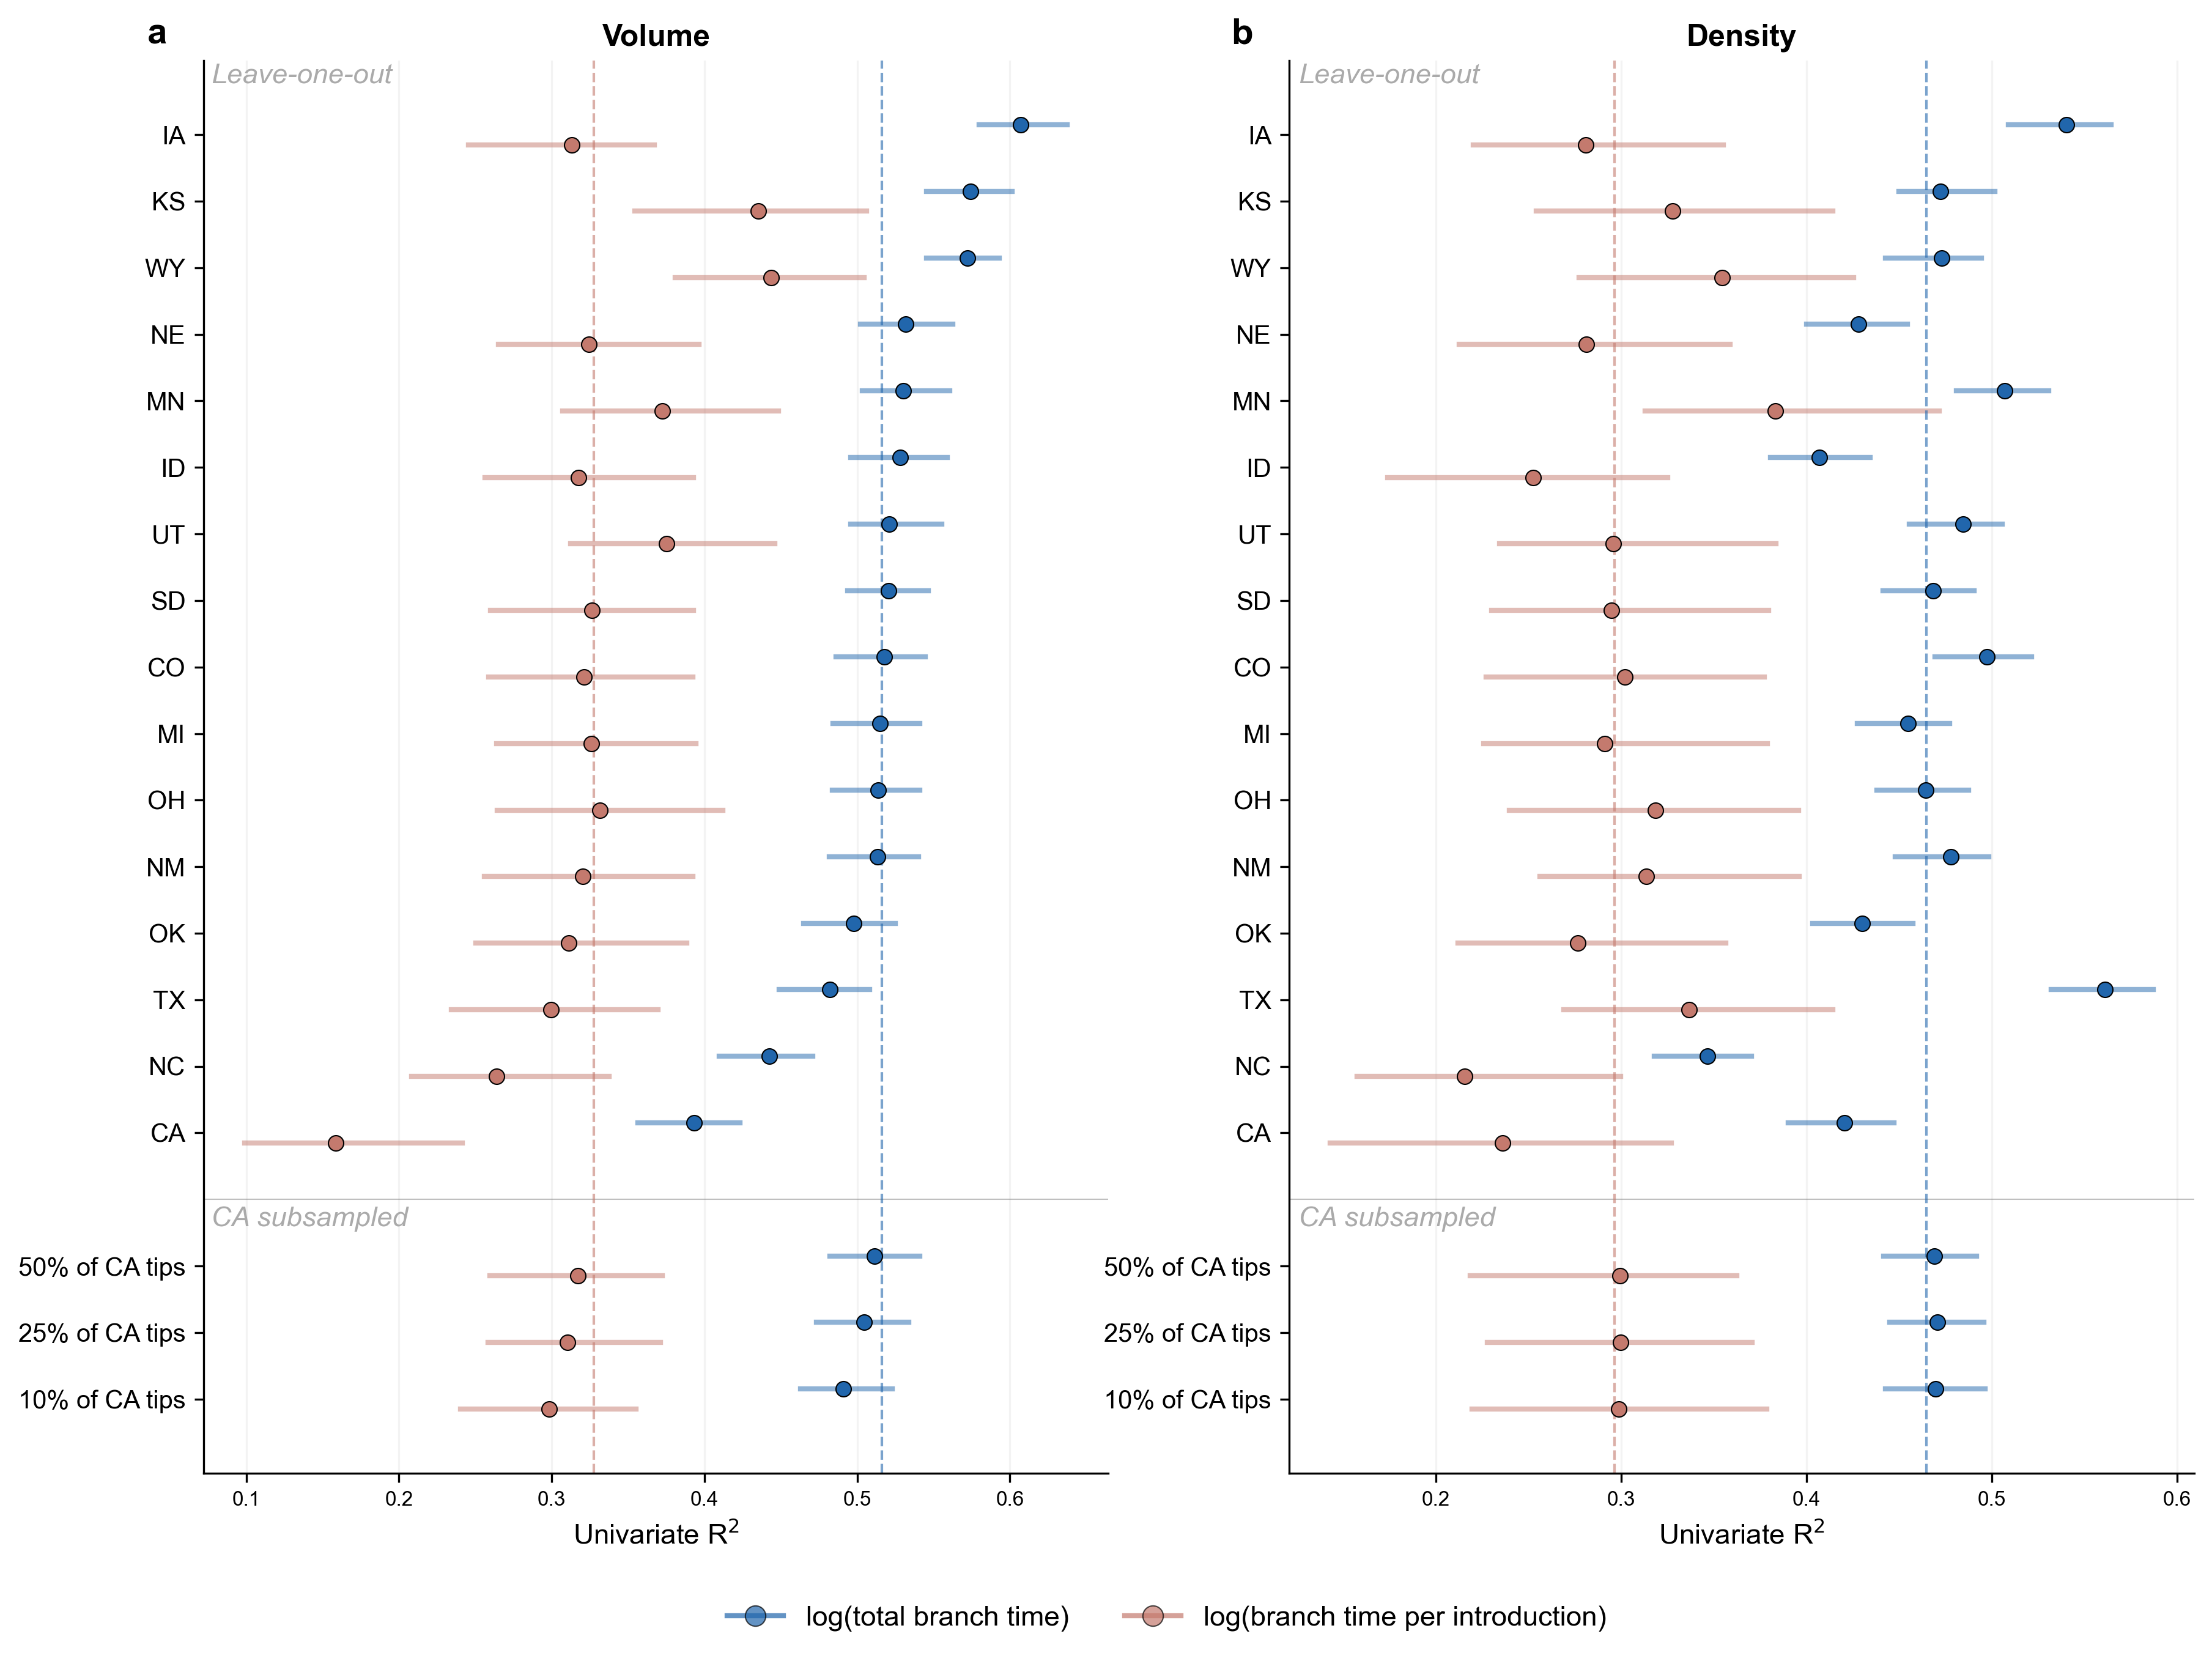


=== Summary ===

Volume:
  Full: BT=0.516, BT/i=0.328
  CA@50%: BT=0.511, BT/i=0.317
  CA@25%: BT=0.504, BT/i=0.310
  CA@10%: BT=0.491, BT/i=0.298

Density:
  Full: BT=0.465, BT/i=0.296
  CA@50%: BT=0.469, BT/i=0.299
  CA@25%: BT=0.471, BT/i=0.300
  CA@10%: BT=0.470, BT/i=0.299


In [7]:
import pickle

RESULTS_PATH = FIG_DIR / 'persistence_loo_results.pkl'
cached = pickle.load(open(RESULTS_PATH, 'rb'))
loo_results = cached['loo_results']
full_r2 = cached['full_r2']
print(f'Loaded results from {RESULTS_PATH}')

CA_FRACS = [0.50, 0.25, 0.10]

vol_bt_medians = {st: np.median(loo_results['volume']['BT'][st]) for st in states}
state_loo_order = sorted(states, key=lambda s: -vol_bt_medians[s])

ca_sub_labels = [f'CA@{int(f*100)}%' for f in CA_FRACS]
all_labels = state_loo_order + ca_sub_labels
n_loo = len(state_loo_order)

# Add a gap between LOO and CA sections
gap = 1.0
positions = list(range(n_loo)) + [n_loo + gap + i for i in range(len(ca_sub_labels))]

fig, (ax_v, ax_d) = plt.subplots(1, 2, figsize=(14, 10))

def draw_panel(ax, feat, label):
    ax.text(-0.04, 1.03, label, transform=ax.transAxes, fontsize=14,
            fontweight='bold', va='top', ha='right')
    off = 0.15
    for yi, (pos, lb) in enumerate(zip(positions, all_labels)):
        for resp, color, dy in [('BT', '#2166ac', -off), ('BT/intro', '#c47a6e', off)]:
            v = loo_results[feat][resp][lb]
            med = np.median(v); lo, hi = hpd(v)
            ax.plot([lo, hi], [pos+dy, pos+dy], color=color, lw=2, alpha=0.5, zorder=2)
            ax.plot(med, pos+dy, 'o', color=color, markersize=6, zorder=5,
                    markeredgecolor='black', markeredgewidth=0.5)
    ax.axhline(n_loo - 0.5 + gap/2, color='grey', ls='-', lw=0.5, alpha=0.5)
    ax.axvline(full_r2[feat]['BT'], color='#2166ac', ls='--', lw=1, alpha=0.6)
    ax.axvline(full_r2[feat]['BT/intro'], color='#c47a6e', ls='--', lw=1, alpha=0.6)
    ax.set_yticks(positions)
    disp = list(state_loo_order) + [f'{int(f*100)}% of CA tips' for f in CA_FRACS]
    ax.set_yticklabels(disp, fontsize=10, color='black')
    ax.invert_yaxis()
    ax.set_xlabel('Univariate R$^2$', fontsize=11)
    ax.set_title(feat.capitalize(), fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.15, axis='x')
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

draw_panel(ax_v, 'volume', 'a')
draw_panel(ax_d, 'density', 'b')

for ax in [ax_v, ax_d]:
    xlim = ax.get_xlim()
    ax.text(xlim[0] + 0.005, -0.7, 'Leave-one-out',
            fontsize=11, fontstyle='italic', color='#aaaaaa',
            va='bottom', ha='left')
    ax.text(xlim[0] + 0.005, n_loo - 0.5 + gap/2 + 0.1, 'CA subsampled',
            fontsize=11, fontstyle='italic', color='#aaaaaa',
            va='top', ha='left')

leg = [
    Line2D([0],[0], marker='o', color='#2166ac', markerfacecolor='#2166ac',
           markersize=8, markeredgecolor='black', markeredgewidth=0.5,
           label='log(total branch time)', lw=2, alpha=0.7),
    Line2D([0],[0], marker='o', color='#c47a6e', markerfacecolor='#c47a6e',
           markersize=8, markeredgecolor='black', markeredgewidth=0.5,
           label='log(branch time per introduction)', lw=2, alpha=0.7),
]
fig.legend(handles=leg, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, 0.01), frameon=False)
fig.savefig(FIG_DIR / 'S_PersistenceLOO.png', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'S_PersistenceLOO.pdf', bbox_inches='tight')
print(f'Saved S_PersistenceLOO to {FIG_DIR}')
plt.show()

print('\n=== Summary ===')
for feat in ['volume', 'density']:
    print(f'\n{feat.capitalize()}:')
    print(f'  Full: BT={full_r2[feat]["BT"]:.3f}, BT/i={full_r2[feat]["BT/intro"]:.3f}')
    for f in CA_FRACS:
        k = f'CA@{int(f*100)}%'
        print(f'  {k}: BT={np.median(loo_results[feat]["BT"][k]):.3f}, '
              f'BT/i={np.median(loo_results[feat]["BT/intro"][k]):.3f}')